# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [48]:
# importar librerías
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as mpy
import seaborn as sns

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isnull().sum())
print()
print(users.isnull().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isnull().sum())
print()
print(usage.isnull().mean())
print ()
calls = usage[usage['type'] == 'call']
texts = usage[usage['type'] == 'text']
print("Duration calls",calls['duration'].isna().mean())
print("Length calls", calls['length'].isna().mean())
print("Duration calls", texts['duration'].isna().mean())
print("Duration calls", texts['length'].isna().mean())
print()

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64

Duration calls 0.0
Length calls 0.9993299084208175
Duration calls 0.9992757559297484
Duration calls 0.0



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

  La tabla users tiene valores nulos en las columnas: city 12% / Churn_date 88%.
  La tabla usage tiene valores nulos en las columnas: date 0.1% / Duration 55.2% / Lenght 44.7%

- Indica qué harías: ¿imputar, eliminar, ignorar?

  Para users: city es un porcentaje bajo y no afecta el sentido del negocio. Lo mantendría y crearía una categoría "Unknown". Churn_date los mantendría por que tiene sentido y significado para el negocio.
  Para Usage: para Duration y length los mantendría, porque tienen sentido para el negocio en este caso los nulos no son datos faltantes sino valores que no aplican. Para Date los eliminaría al ser pocos y representar un dato necesario para cada registro

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


La columna user_id: Columna secuencial y con valores unicos.
La columna age: muestra una edad minima de -999 la cual no es válida y afecta la estadistica descriptiva.

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


Las columnas id y user_id: Columnas secuencial que funcionan como identificador de cada registro y usuario.
Las columnas duration y lenght presentan nulos esperados por el tipo de evento que no representan valores inválidos o sentinnels.

In [21]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n{'='*50}")
    print(f"Columna: {col}")
    print(f"{'='*50}")

    print(f"Valores únicos: {users[col].nunique()}")
    print(f"Nulos: {users[col].isna().sum()}")

    print("\nFrecuencias:")
  
  print(users[col].value_counts(dropna=False))

    print("\nPorcentajes (%):")
    print(round(users[col].value_counts(dropna=False, normalize=True) * 100, 2))




Columna: city
Valores únicos: 7
Nulos: 469

Frecuencias:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Porcentajes (%):
Bogotá      20.20
CDMX        18.25
Medellín    15.40
NaN         11.72
GDL         11.25
Cali        10.60
MTY         10.17
?            2.40
Name: city, dtype: float64

Columna: plan
Valores únicos: 2
Nulos: 0

Frecuencias:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Porcentajes (%):
Basico     64.88
Premium    35.12
Name: plan, dtype: float64


- La columna `city`, presenta 469 valores nulos y 96 registros sin definir ciudad identificado con "?"
- La columna `plan`, No presenta valores nulos.

In [22]:
# explorar columna categórica de usage
for col in ['type']:
    print(f"\n{'='*50}")
    print(f"Columna: {col}")
    print(f"{'='*50}")

    print(f"Valores únicos: {usage[col].nunique()}")
    print(f"Nulos: {usage[col].isna().sum()}")

    print("\nFrecuencias:")
    print(usage[col].value_counts(dropna=False))

    print("\nPorcentajes (%):")
    print(round(usage[col].value_counts(dropna=False, normalize=True) * 100, 2))


Columna: type
Valores únicos: 2
Nulos: 0

Frecuencias:
text    22092
call    17908
Name: type, dtype: int64

Porcentajes (%):
text    55.23
call    44.77
Name: type, dtype: float64


- La columna `type`, no presenta valores nulos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  En age se identificó el valor -999, utilizado como sentinel para representar edades desconocidas.
  En city se identificó el valor "?", utilizado como marcador de ciudad no especificada.
  Los valores nulos observados en duration y length no son errores, ya que dependen del tipo de evento (call o text).
- ¿Qué acción tomarías?
Reemplazar -999 por NaN en age.
Reemplazar "?" por NaN en city.
Mantener los nulos de duration y length porque representan campos no aplicables según el tipo de registro.
Evaluar posteriormente si los nulos de city y age deben imputarse o mantenerse según los objetivos del análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [23]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [24]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [31]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, La mayoria de registros sucede entre 2022 y 2024, sin embargo hay 40 registros en el año 2026.

In [30]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, solo se registran usos para el año 2024.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?
  Se identificaron 40 registros con fecha de registro en 2026, mientras que toda la actividad de uso ocurre en 2024. Estos valores no son imposibles en términos de calendario, pero sí son inconsistentes con el período analizado y podrían corresponder a errores de captura o calidad de datos. Se recomienda revisarlos individualmente y, en caso de no poder corregirlos, convertirlos en valores nulos o excluirlos del análisis para evitar sesgos en los resultados.
- ¿Qué harías con ellas?
Excluir esos registros del análisis si representan una proporción pequeña de los datos (40 de 4000 usuarios = 1%).

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [33]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)
# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [35]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
users['city'].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [37]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [38]:
# Verificación MAR en usage (Missing At Random) para duration
# Nulos de duration según type
pd.crosstab(
    usage['type'],
    usage['duration'].isna(),
    margins=True)

duration,False,True,All
type,,,
call,17908,0,17908
text,16,22076,22092
All,17924,22076,40000


In [40]:
# Verificación MAR en usage (Missing At Random) para length
# Nulos de length según type
pd.crosstab(
    usage['type'],
    usage['length'].isna(),
    margins=True)

length,False,True,All
type,,,
call,12,17896,17908
text,22092,0,22092
All,22104,17896,40000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`.
Se verificó la relación entre los valores nulos de duration y length con la variable type mediante tablas de contingencia. Se observó que los nulos dependen completamente del tipo de evento: las llamadas registran duración pero no longitud de mensaje, mientras que los mensajes de texto registran longitud pero no duración. Debido a que estos valores faltantes están explicados por una variable observada (type), se consideran MAR y se mantienen como nulos, ya que representan campos no aplicables y no errores en los datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [41]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
# Agrupar información por usuario
usage_agg = (usage.groupby("user_id").agg(total_messages=("is_text", "sum"),total_calls=("is_call", "sum"),total_call_minutes=("duration", "sum")).reset_index())
# observar resultado
usage_agg.head(3)

,user_id,total_messages,total_calls,total_call_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [42]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "total_messages": "cant_mensajes",
    "total_calls": "cant_llamadas",
    "total_call_minutes": "cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [43]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id",how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [44]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada']
user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [46]:
# Distribución porcentual del tipo de plan
pd.DataFrame({'Frecuencia': user_profile['plan'].value_counts(),'Porcentaje (%)': round(user_profile['plan'].value_counts(normalize=True) * 100,2)})

,Frecuencia,Porcentaje (%)
Basico,2595,64.88
Premium,1405,35.12


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

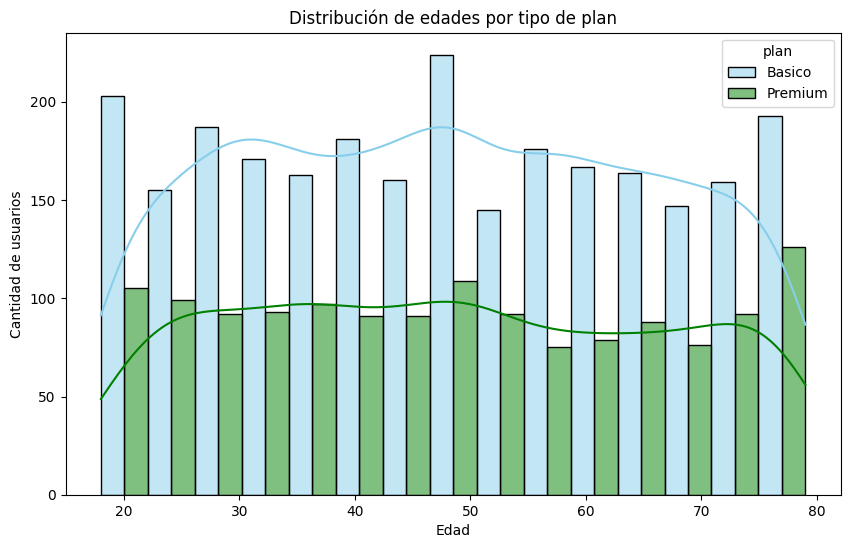

In [56]:
# Histograma para visualizar la edad (age)
mpy.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], bins=15, multiple='dodge', kde=True)
mpy.title('Distribución de edades por tipo de plan')
mpy.xlabel('Edad')
mpy.ylabel('Cantidad de usuarios')
mpy.show()

💡Insights: 
- La distribución de edades es amplia y relativamente uniforme para ambos tipos de plan. Aunque el plan Básico presenta una mayor cantidad de usuarios, esto se debe al mayor tamaño de esa categoría en la muestra. Las curvas de densidad muestran patrones muy similares entre los planes Básico y Premium, lo que sugiere que la edad no constituye un factor diferenciador importante en la selección del plan. No se identificaron valores atípicos ni concentraciones significativas en rangos específicos de edad.

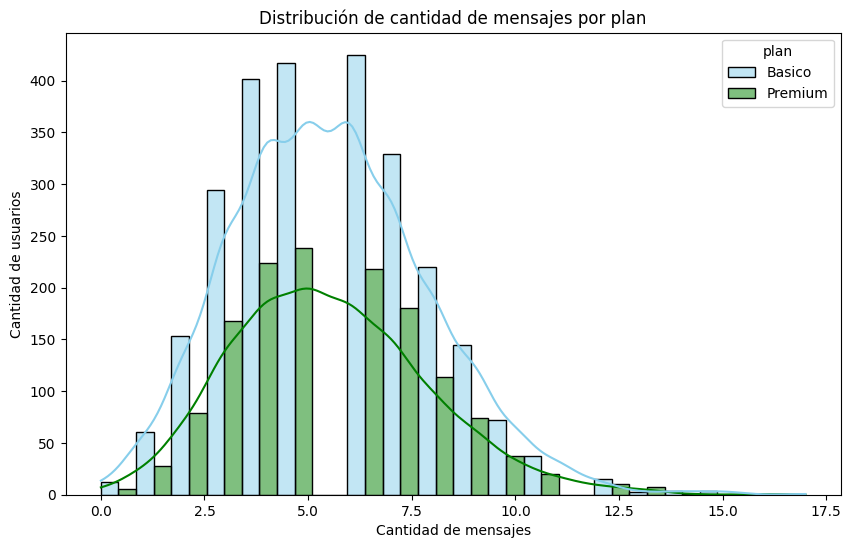

In [57]:
# Histograma para visualizar la cant_mensajes
mpy.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], bins=20, multiple='dodge', kde=True)
mpy.title('Distribución de cantidad de mensajes por plan')
mpy.xlabel('Cantidad de mensajes')
mpy.ylabel('Cantidad de usuarios')
mpy.show()

💡Insights: 
- La cantidad de mensajes presenta una distribución unimodal y ligeramente sesgada a la derecha para ambos tipos de plan. La mayoría de los usuarios envía entre 4 y 7 mensajes durante el período analizado, mientras que un número reducido registra niveles de actividad más altos. Las distribuciones de los planes Básico y Premium muestran formas muy similares, por lo que no se evidencia una diferencia significativa en el comportamiento de mensajería asociada al tipo de plan. La mayor frecuencia observada en el plan Básico se explica principalmente por el mayor número de usuarios pertenecientes a dicha categoría.

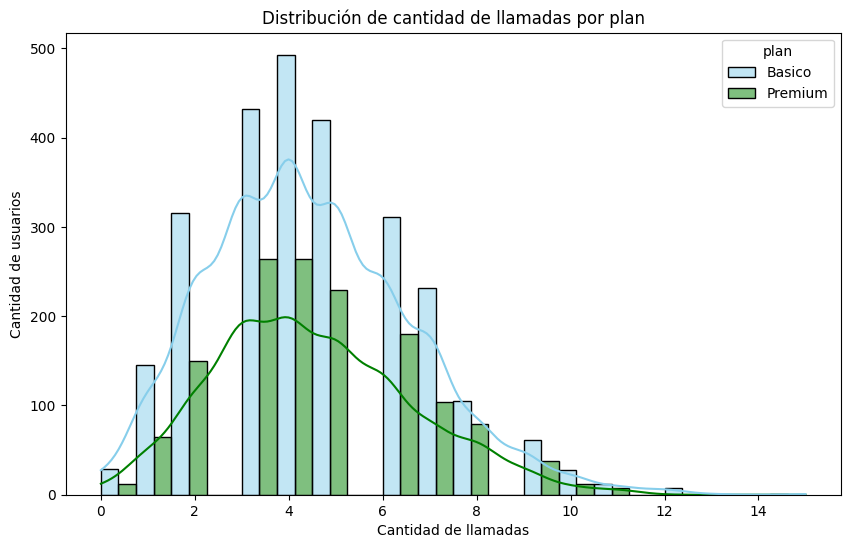

In [58]:
# Histograma para visualizar la cant_llamadas
mpy.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], bins=20,multiple='dodge',kde=True)
mpy.title('Distribución de cantidad de llamadas por plan')
mpy.xlabel('Cantidad de llamadas')
mpy.ylabel('Cantidad de usuarios')
mpy.show()

💡Insights: 
- La cantidad de llamadas presenta una distribución unimodal y sesgada a la derecha para ambos tipos de plan. La mayoría de los usuarios realiza entre 3 y 6 llamadas durante el período analizado, mientras que un número reducido registra una actividad más intensa. Las distribuciones de los planes Básico y Premium son muy similares, lo que sugiere patrones de uso comparables entre ambos grupos. Aunque los usuarios Premium muestran una ligera presencia en los rangos más altos de llamadas, visualmente no se observa una diferencia sustancial que permita concluir que el tipo de plan influye significativamente en la cantidad de llamadas realizadas.

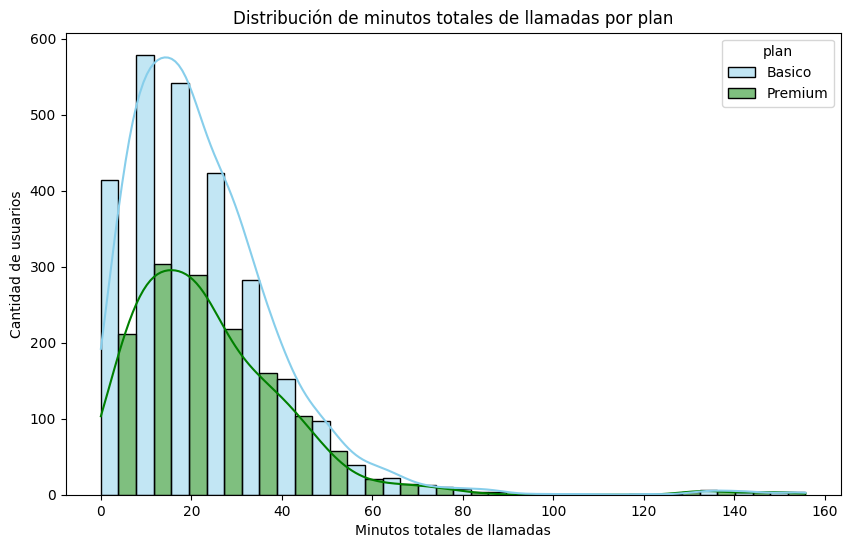

In [60]:
# Histograma para visualizar la cant_minutos_llamada
mpy.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], bins=20,multiple='dodge', kde=True)
mpy.title('Distribución de minutos totales de llamadas por plan')
mpy.xlabel('Minutos totales de llamadas')
mpy.ylabel('Cantidad de usuarios')
mpy.show()

💡Insights: 
- La distribución de los minutos totales de llamadas presenta un marcado sesgo positivo para ambos tipos de plan. La mayoría de los usuarios acumula entre 10 y 30 minutos de llamadas durante el período analizado, mientras que un número reducido registra consumos considerablemente más altos, generando una cola larga hacia la derecha. Las distribuciones de los planes Básico y Premium son similares en forma y rango, aunque el plan Premium muestra una ligera tendencia a concentrar usuarios con mayores tiempos de conversación. En general, no se observan diferencias sustanciales entre los planes únicamente a partir de la inspección visual del histograma.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

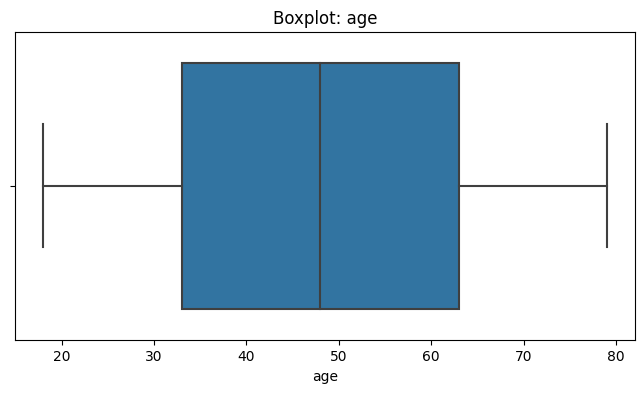

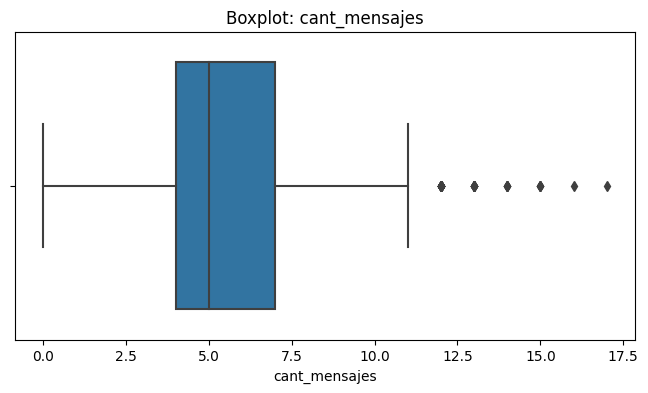

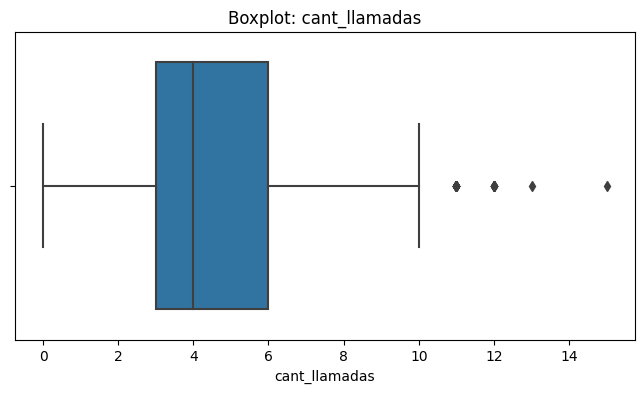

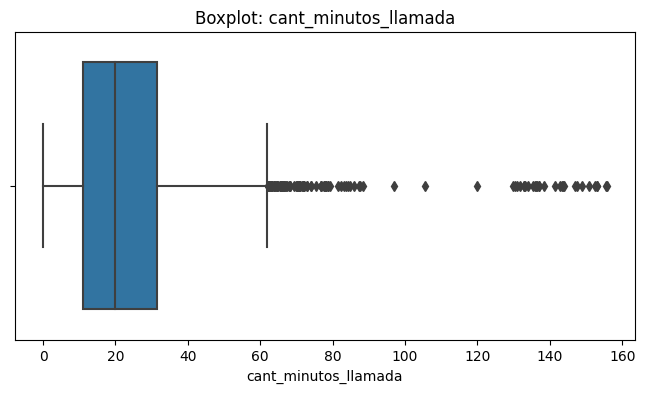

In [63]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    mpy.figure(figsize=(8,4)) 
    sns.boxplot(x=user_profile[col])
    mpy.title(f'Boxplot: {col}')
    mpy.xlabel(col)
    mpy.show()

💡Insights: 
- Age: no presenta outliers.
- cant_mensajes: Presenta outliers.
- cant_llamadas: Presenta outliers.
- cant_minutos_llamada: Presenta outliers.

In [68]:
# Calcular límites con el método IQR
columnas_limites = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = user_profile[
        (user_profile[col] < limite_inferior) |
        (user_profile[col] > limite_superior)]

    print(f"\n{'='*50}")
    print(f"Variable: {col}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Cantidad de outliers: {len(outliers)}")


Variable: age
Límite inferior: -12.00
Límite superior: 108.00
Cantidad de outliers: 0

Variable: cant_mensajes
Límite inferior: -0.50
Límite superior: 11.50
Cantidad de outliers: 46

Variable: cant_llamadas
Límite inferior: -1.50
Límite superior: 10.50
Cantidad de outliers: 30

Variable: cant_minutos_llamada
Límite inferior: -19.32
Límite superior: 61.86
Cantidad de outliers: 109


In [65]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener, por que los usuarios con más de 11 mensajes son considerados atípicos según el criterio IQR y representan apenas el 1.15%.
- cant_llamadas: mantener, por que los usuarios con más de 10 llamadas son considerados atípicos y representan apenas el 0.75%.
- cant_minutos_llamada: Mmantener, por que acumulan más de 61.86 minutos aparecen como atípicos y representan apenas el 2.73%.
- Además estos valores representan comportamientos reales de usuarios con un uso intensivo del servicio y no errores de captura o medición, se decidió conservarlos en el conjunto de datos. Eliminarlos podría sesgar el análisis y reducir la capacidad de identificar diferencias entre los tipos de plan.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [69]:
# Crear columna grupo_uso
def clasificar_uso(fila):
    
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
    
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [70]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [71]:
# Crear columna grupo_edad
def clasificar_edad(edad):

    if edad < 30:
        return 'Joven'

    elif edad < 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [72]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

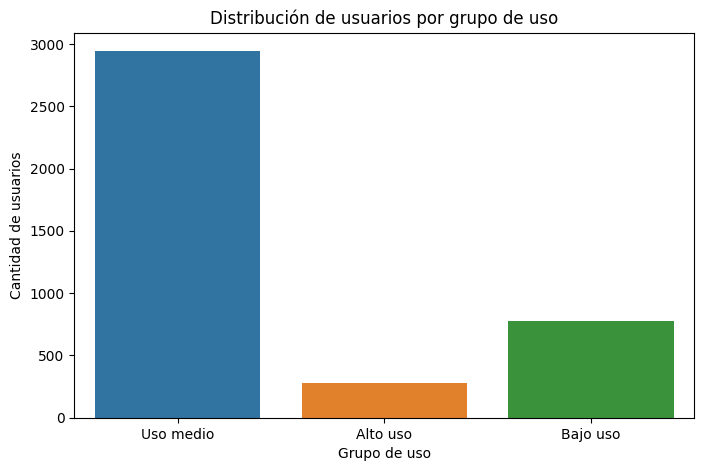

In [74]:
# Visualización de los segmentos por uso
mpy.figure(figsize=(8,5))
sns.countplot(data=user_profile,x='grupo_uso')
mpy.title('Distribución de usuarios por grupo de uso')
mpy.xlabel('Grupo de uso')
mpy.ylabel('Cantidad de usuarios')
mpy.show()

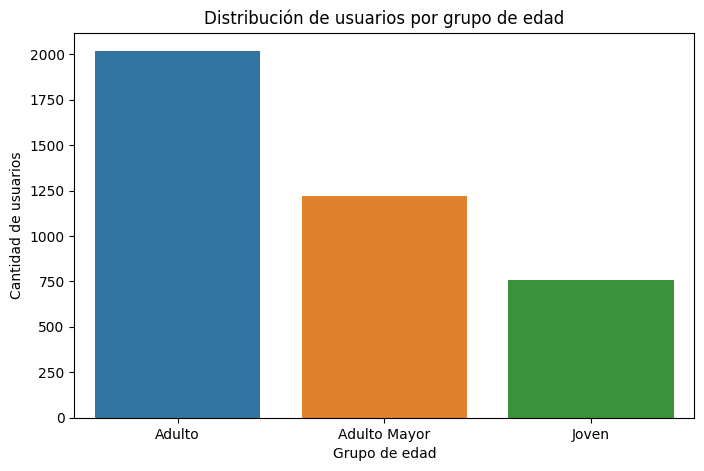

In [76]:
# Visualización de los segmentos por edad
mpy.figure(figsize=(8,5)) 
sns.countplot(data=user_profile, x='grupo_edad')
mpy.title('Distribución de usuarios por grupo de edad')
mpy.xlabel('Grupo de edad')
mpy.ylabel('Cantidad de usuarios')
mpy.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Durante la etapa de calidad de datos se identificaron valores faltantes, sentinels y fechas inconsistentes.
- Los principales problemas se concentraron en la variable ciudad, donde el 11.72% de los registros eran nulos y el 2.40% utilizaban el valor "?" como marcador de información desconocida.
- Se detectaron edades inválidas representadas por -999 y 40 fechas de registro fuera del rango temporal del análisis.
- Se encontraron altos porcentajes de nulos en las variables duration y length; sin embargo, estos se explican por la naturaleza de los datos y no corresponden a errores, ya que cada variable aplica únicamente a un tipo específico de evento (llamada o mensaje). 

🔍 **Segmentos por Edad**
- Jóvenes (< 30 años): representan usuarios relativamente recientes y con potencial afinidad hacia servicios digitales y mensajería.
- Adultos (30 a 59 años): constituyen probablemente el segmento más grande de la base de clientes y presentan patrones de uso equilibrados.
- Adultos mayores (≥ 60 años): muestran un uso más tradicional del servicio, posiblemente con mayor dependencia de llamadas que de mensajes.


📊 **Segmentos por Nivel de Uso**
- Bajo uso: usuarios con menos de 5 llamadas y menos de 5 mensajes. Son clientes con poca interacción con la red.
- Uso medio: usuarios con consumos moderados de llamadas y mensajes. Representan el comportamiento típico de la mayoría de la cartera.
- Alto uso: usuarios que superan los umbrales establecidos de llamadas o mensajes. Son los clientes más activos y con mayor consumo de servicios.

💡 **Recomendaciones**
Esto sugiere que los usuarios de alto consumo constituyen el grupo de mayor valor para ConnectaTel debido a su elevada utilización de llamadas y mensajería. Asimismo, se detectaron patrones de uso extremo que representan oportunidades para desarrollar ofertas especializadas orientadas a clientes intensivos. La creación de planes escalonados según el nivel de consumo y la implementación de estrategias de migración hacia planes superiores podrían mejorar la rentabilidad, la retención de clientes y la adecuación de la oferta comercial a las necesidades reales de los usuarios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`